In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as tts
from sklearn import preprocessing
from sklearn import svm
from sklearn import metrics
import pickle

In [42]:
data = pd.read_csv("loan.csv")
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [43]:
data.drop("Loan_ID",axis=1,inplace=True)
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
593,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [44]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [45]:
data.shape

(598, 12)

In [46]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             598 non-null    str    
 1   Married            598 non-null    str    
 2   Dependents         586 non-null    float64
 3   Education          598 non-null    str    
 4   Self_Employed      598 non-null    str    
 5   ApplicantIncome    598 non-null    int64  
 6   CoapplicantIncome  598 non-null    float64
 7   LoanAmount         577 non-null    float64
 8   Loan_Amount_Term   584 non-null    float64
 9   Credit_History     549 non-null    float64
 10  Property_Area      598 non-null    str    
 11  Loan_Status        598 non-null    str    
dtypes: float64(5), int64(1), str(6)
memory usage: 56.2 KB


In [47]:
data.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [48]:
data.isnull().sum()

Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [49]:
data.dropna(inplace=True)

In [50]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [51]:
data.duplicated().sum()

np.int64(0)

In [52]:
encoder = preprocessing.LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object" or data[col].dtype == "str" or data[col].dtype == "string":
        print("-----------before------------")
        print(data[col].value_counts())
        data[col] = encoder.fit_transform(data[col])
        print("-----------after-------------")
        print(data[col].value_counts())
        print("🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠")

-----------before------------
Gender
Male      412
Female     93
Name: count, dtype: int64
-----------after-------------
Gender
1    412
0     93
Name: count, dtype: int64
🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠
-----------before------------
Married
Yes    324
No     181
Name: count, dtype: int64
-----------after-------------
Married
1    324
0    181
Name: count, dtype: int64
🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠
-----------before------------
Education
Graduate        402
Not Graduate    103
Name: count, dtype: int64
-----------after-------------
Education
0    402
1    103
Name: count, dtype: int64
🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠
-----------before------------
Self_Employed
No     414
Yes     91
Name: count, dtype: int64
-----------after-------------
Self_Employed
0    414
1     91
Name: count, dtype: int64
🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠
-----------before------------
Property_Area
Semiurban    200
Urban        156
Rural        149
Name: count, dtype: int64
-----------after-------------
Property_Area
1    200
2    156
0    149
Name: count, dtype: int64
🟠🟠🟠🟠

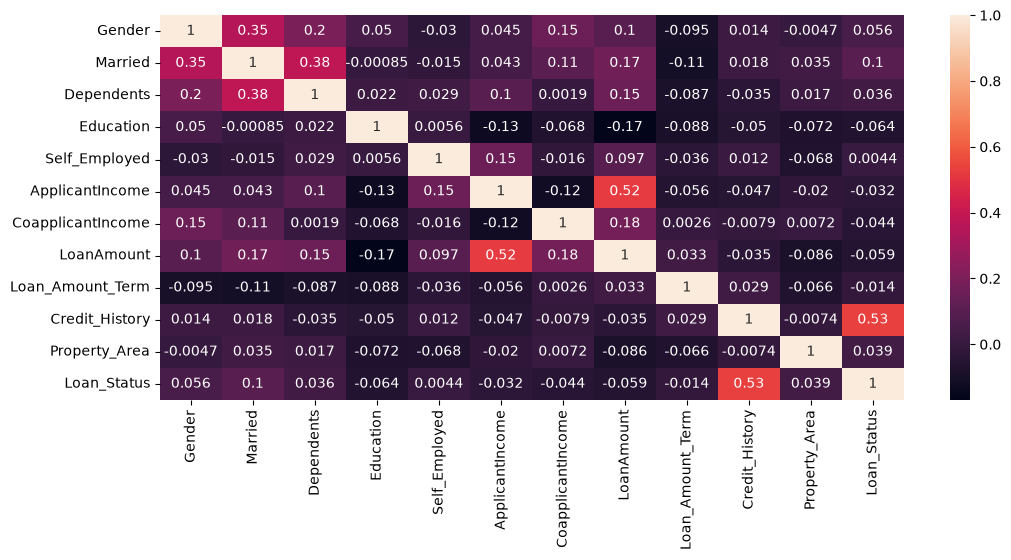

In [53]:
plt.figure(figsize=(12,5))
sns.heatmap(data.corr(),annot=True)
plt.show()

In [54]:
abs(data.corr()["Loan_Status"]) > 0.01

Gender                True
Married               True
Dependents            True
Education             True
Self_Employed        False
ApplicantIncome       True
CoapplicantIncome     True
LoanAmount            True
Loan_Amount_Term      True
Credit_History        True
Property_Area         True
Loan_Status           True
Name: Loan_Status, dtype: bool

In [55]:
to_drop = []
for col in data.columns:
    if abs(data.corr()["Loan_Status"][col]) < 0.02:
        to_drop.append(col)
print(to_drop)
data.drop(to_drop,axis=1,inplace=True)

['Self_Employed', 'Loan_Amount_Term']


In [56]:
x = data.drop("Loan_Status",axis=1)
y = data["Loan_Status"]

In [57]:
x_train,x_test,y_train,y_test = tts(x,
                                    y,
                                    test_size=0.2,
                                    random_state=42)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((404, 9), (101, 9), (404,), (101,))

In [58]:
scaler = preprocessing.MinMaxScaler((0,1))

x_cols = x_train.columns
x_train = pd.DataFrame(scaler.fit_transform(x_train),
                       columns=x_cols)
x_test = pd.DataFrame(scaler.transform(x_test),
                      columns=x_cols)

In [59]:
x_train.describe()

,Gender,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Property_Area
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.819307,0.633663,0.254950,0.215347,0.082104,0.046595,0.226617,0.858911,0.487624
std,0.385241,0.482400,0.342174,0.411572,0.086178,0.080784,0.139000,0.348545,0.385655
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.042327,0.000000,0.153553,1.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.058588,0.032686,0.196277,1.000000,0.500000
75%,1.000000,1.000000,0.666667,0.000000,0.089666,0.066495,0.259729,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [60]:
model_svm1 = svm.SVC(kernel="linear")
model_svm1.fit(x_train,y_train)
y_pred1 = model_svm1.predict(x_test)
metrics.accuracy_score(y_test,y_pred1)*100

89.10891089108911

In [61]:
model_svm2 = svm.SVC(kernel="poly")
model_svm2.fit(x_train,y_train)
y_pred2 = model_svm2.predict(x_test)
metrics.accuracy_score(y_test,y_pred2)*100

88.11881188118812

In [62]:
model_svm3 = svm.SVC(kernel="rbf")
model_svm3.fit(x_train,y_train)
y_pred3 = model_svm3.predict(x_test)
metrics.accuracy_score(y_test,y_pred3)*100

88.11881188118812

In [63]:
model_svm4 = svm.SVC(kernel="sigmoid")
model_svm4.fit(x_train,y_train)
y_pred4 = model_svm4.predict(x_test)
metrics.accuracy_score(y_test,y_pred4)*100

54.45544554455446

In [64]:
with open("model_loan.pkl","wb") as file:
    pickle.dump(model_svm1, file)

In [65]:
with open("scaler.pkl","wb") as file:
    pickle.dump(scaler, file)

In [66]:
x_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'ApplicantIncome',
       'CoapplicantIncome', 'LoanAmount', 'Credit_History', 'Property_Area'],
      dtype='str')